<a href="https://colab.research.google.com/github/EdgarErh/Mineria_de_datos/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer parcial

In [ ]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

In [ ]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

In [ ]:
distancias = []
for i in range(len(X)):
    d = distancia_euclidiana(P, X[i])
    distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


In [ ]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])


Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


In [ ]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


##KNN sin normalizacion

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Dataset
X = np.array([
[25, 8000],
[30, 12000],
[45, 45000],
[50, 60000],
[35, 15000],
[48, 55000]
])

y = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])

nuevo_cliente = np.array([[40, 20000]])

# Modelo k-NN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

# Predicción
modelo.predict(nuevo_cliente)

array(['Alto'], dtype='<U4')

##Parte B: k‑NN CON normalización

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalamiento
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
nuevo_norm = scaler.transform(nuevo_cliente)

# Modelo k-NN
modelo_norm = KNeighborsClassifier(n_neighbors=3)
modelo_norm.fit(X_norm, y)

# Predicción
modelo_norm.predict(nuevo_norm)

array(['Alto'], dtype='<U4')

In [ ]:
X_norm

array([[-1.47069757, -1.14533092],
       [-0.93912013, -0.95833812],
       [ 0.65561217,  0.58435251],
       [ 1.1871896 ,  1.28557552],
       [-0.4075427 , -0.81809351],
       [ 0.97455863,  1.05183452]])

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


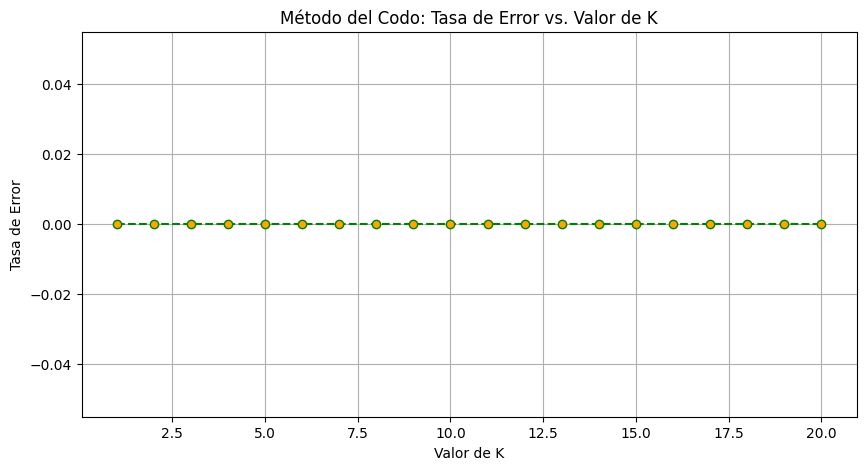

--- Evaluación con K=3 ---
Precisión: 100.00%

Reporte detallado:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

RESULTADO DEL EJERCICIO K-NN
Valor de K seleccionado: 3
Precisión del modelo: 100.00%
Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Cargar el dataset desde seaborn
iris = sns.load_dataset('iris')

# 2. Separar características (X) y etiqueta (y)
# X = todas las columnas excepto 'species'
# y = solo la columna 'species'
X = iris.drop('species', axis=1)
y = iris['species']

# 3. Separación de datos: Entrenamiento 80% y Prueba 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Escalamiento (Siguiendo tu código base)
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# 5. Determinación del valor de K (Método del Codo)
tasa_error = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_norm, y_train)
    pred_i = knn.predict(X_test_norm)
    tasa_error.append(np.mean(pred_i != y_test))

# 6. Graficar el Codo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), tasa_error, color='green', linestyle='dashed', marker='o', markerfacecolor='orange')
plt.title('Método del Codo: Tasa de Error vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.grid(True)
plt.show()

# 7. Determinar K adecuado y evaluar
k_elegido = 3
modelo_final = KNeighborsClassifier(n_neighbors=k_elegido)
modelo_final.fit(X_train_norm, y_train)
predicciones = modelo_final.predict(X_test_norm)

print(f"--- Evaluación con K={k_elegido} ---")
print(f"Precisión: {accuracy_score(y_test, predicciones) * 100:.2f}%")
print("\nReporte detallado:")
print(classification_report(y_test, predicciones))
# --- Valor de K elegido para la impresión ---
k_adecuado = 3

# Volvemos a entrenar con el valor seleccionado
modelo_final = KNeighborsClassifier(n_neighbors=k_adecuado)
modelo_final.fit(X_train_norm, y_train)

# Predicciones finales
predicciones = modelo_final.predict(X_test_norm)
exactitud = accuracy_score(y_test, predicciones)

print("==========================================")
print(f"RESULTADO DEL EJERCICIO K-NN")
print("==========================================")
print(f"Valor de K seleccionado: {k_adecuado}")
print(f"Precisión del modelo: {exactitud * 100:.2f}%")
print("==========================================")
print("Reporte de Clasificación:")
print(classification_report(y_test, predicciones))